# 10 — Comparativa final de modelos

**Proyecto:** RepostaPro — Optimización del repostaje en flotas comerciales  
**Autor:** Víctor González Martín  
**Notebook:** 10 — Comparativa cruzada y selección del modelo de producción

## Objetivo del notebook

Consolidar los resultados de los tres modelos entrenados en la Fase 4 (Baseline, Prophet, LightGBM) en una tabla comparativa única que permita:

1. Identificar el modelo ganador por combinación carburante × régimen.
2. Justificar la selección del modelo de producción del sistema RepostaPro.
3. Analizar la importancia relativa de las features en el modelo ganador.
4. Documentar limitaciones y líneas de mejora futura.

## Modelos comparados

| # | Modelo | Paradigma | Granularidad |
|---|---|---|---|
| 1 | Baseline (MM7) por estación | Regla aritmética | Estación individual |
| 2 | Baseline (MM7) nacional | Regla aritmética | Agregado nacional |
| 3 | Prophet (Meta) | Series temporales | Agregado nacional |
| 4 | LightGBM (Microsoft) | Gradient boosting tabular | Estación individual |

## Criterios de evaluación

- **MAE en test**: métrica principal.
- **Granularidad funcional**: capacidad de predecir estaciones individuales.
- **Robustez por régimen**: comportamiento en pre-shock y post-shock.
- **Coste computacional**: tiempo de entrenamiento e inferencia.

In [17]:
# Configuración del entorno
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

# Añadir raíz del proyecto al sys.path
RAIZ_PROYECTO = Path("..").resolve()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

# Importar funciones del módulo
from src.modelos import importancia_features_lightgbm, cargar_modelo_lightgbm

# Rutas
CARPETA_RESULTADOS = Path("../outputs/resultados_modelos")
CARPETA_MODELOS_LGB = Path("../outputs/models/lightgbm")
CARPETA_FIGURAS = Path("../outputs/figures")

# Cargar resultados de los 3 modelos
df_baseline = pd.read_csv(CARPETA_RESULTADOS / "baseline_resultados.csv")
df_baseline_nacional = pd.read_csv(CARPETA_RESULTADOS / "baseline_nacional_resultados.csv")
df_prophet = pd.read_csv(CARPETA_RESULTADOS / "prophet_resultados.csv")

print(f"Resultados cargados:")
print(f"Baseline estación:  {len(df_baseline)} evaluaciones")
print(f"Baseline nacional:  {len(df_baseline_nacional)} evaluaciones")
print(f"Prophet:            {len(df_prophet)} evaluaciones")

Resultados cargados:
Baseline estación:  12 evaluaciones
Baseline nacional:  12 evaluaciones
Prophet:            12 evaluaciones


## Cargar resultados de LightGBM

Como el notebook `09_modelo_lightgbm.ipynb` no exportó los resultados a CSV (los teníamos solo en memoria), los reconstruimos manualmente a partir de los outputs documentados.

In [18]:
# Resultados de LightGBM (extraídos del notebook 09)
resultados_lgb = [
    # Gasóleo A · Pre-shock
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLEO_A · pre shock · train",
     "n_observaciones": 6996238, "mae_cts": 0.150, "rmse_cts": 0.279, "mape_pct": 0.106},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLEO_A · pre shock · val",
     "n_observaciones": 1017945, "mae_cts": 0.249, "rmse_cts": 0.395, "mape_pct": 0.182},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLEO_A · pre shock · test",
     "n_observaciones": 651949, "mae_cts": 0.456, "rmse_cts": 0.570, "mape_pct": 0.330},
    
    # Gasóleo A · Post-shock
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLEO_A · post shock · train",
     "n_observaciones": 687425, "mae_cts": 0.553, "rmse_cts": 0.907, "mape_pct": 0.322},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLEO_A · post shock · val",
     "n_observaciones": 269279, "mae_cts": 2.452, "rmse_cts": 2.731, "mape_pct": 1.434},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLEO_A · post shock · test",
     "n_observaciones": 236037, "mae_cts": 6.639, "rmse_cts": 7.089, "mape_pct": 4.093},
    
    # Gasolina 95 · Pre-shock
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLINA_95 · pre shock · train",
     "n_observaciones": 6759112, "mae_cts": 0.269, "rmse_cts": 0.508, "mape_pct": 0.177},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLINA_95 · pre shock · val",
     "n_observaciones": 985129, "mae_cts": 0.534, "rmse_cts": 0.796, "mape_pct": 0.371},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLINA_95 · pre shock · test",
     "n_observaciones": 631170, "mae_cts": 0.872, "rmse_cts": 1.123, "mape_pct": 0.607},
    
    # Gasolina 95 · Post-shock
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLINA_95 · post shock · train",
     "n_observaciones": 664995, "mae_cts": 0.474, "rmse_cts": 0.784, "mape_pct": 0.301},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLINA_95 · post shock · val",
     "n_observaciones": 260617, "mae_cts": 0.411, "rmse_cts": 0.644, "mape_pct": 0.264},
    {"modelo": "lightgbm", "nombre": "LightGBM · GASOLINA_95 · post shock · test",
     "n_observaciones": 228394, "mae_cts": 0.402, "rmse_cts": 0.616, "mape_pct": 0.267},]

df_lightgbm = pd.DataFrame(resultados_lgb)
df_lightgbm.to_csv(CARPETA_RESULTADOS / "lightgbm_resultados.csv", index=False)

print(f"Resultados de LightGBM consolidados ({len(df_lightgbm)} filas)")
print(f"Guardado en: lightgbm_resultados.csv")

Resultados de LightGBM consolidados (12 filas)
Guardado en: lightgbm_resultados.csv


## Tabla comparativa cruzada en TEST

Construimos la tabla principal de la comparativa: MAE en test por combinación carburante × régimen.

In [19]:
import re

def extraer_combinacion(nombre):
    """Extrae 'GASOLEO_A · PRE SHOCK' o similar de cualquier formato de nombre."""
    nombre_upper = nombre.upper()
    
    # Detectar carburante
    if "GASOLEO" in nombre_upper or "GASÓLEO" in nombre_upper:
        carburante = "GASOLEO_A"
    elif "GASOLINA" in nombre_upper:
        carburante = "GASOLINA_95"
    else:
        return None
    
    # Detectar régimen
    if "POST" in nombre_upper:
        regimen = "POST SHOCK"
    elif "PRE" in nombre_upper:
        regimen = "PRE SHOCK"
    else:
        return None
    
    return f"{carburante} · {regimen}"


def filtrar_test(df, etiqueta_modelo):
    """Extrae filas de test y normaliza el nombre de la combinación."""
    sub = df[df["nombre"].str.contains("test", case=False, na=False)].copy()
    sub["combinacion"] = sub["nombre"].apply(extraer_combinacion)
    sub = sub.dropna(subset=["combinacion"])
    sub["modelo_etiqueta"] = etiqueta_modelo
    return sub[["combinacion", "modelo_etiqueta", "mae_cts", "rmse_cts", "mape_pct"]]


# Aplicar a los 4 conjuntos de resultados
baseline_test = filtrar_test(df_baseline, "Baseline (estación)")
baseline_nacional_test = filtrar_test(df_baseline_nacional, "Baseline (nacional)")
prophet_test = filtrar_test(df_prophet, "Prophet")
lightgbm_test = filtrar_test(df_lightgbm, "LightGBM")

# Pivotar a tabla cruzada
todos_test = pd.concat([baseline_test, baseline_nacional_test, prophet_test, lightgbm_test])
tabla_comparativa = todos_test.pivot_table(
    index="combinacion", columns="modelo_etiqueta", values="mae_cts").round(3)

# Reordenar columnas
orden_modelos = ["Baseline (estación)", "Baseline (nacional)", "Prophet", "LightGBM"]
tabla_comparativa = tabla_comparativa[orden_modelos]

# Añadir ganador
tabla_comparativa["Ganador"] = tabla_comparativa[orden_modelos].idxmin(axis=1)
tabla_comparativa["Mejor MAE"] = tabla_comparativa[orden_modelos].min(axis=1).round(3)

print("=" * 110)
print("COMPARATIVA DE MODELOS — MAE en TEST (céntimos por litro)")
print("=" * 110)
print(tabla_comparativa.to_string())
print("=" * 110)

# Guardar
tabla_comparativa.to_csv(CARPETA_RESULTADOS / "comparativa_modelos_test.csv")
print(f"\nTabla guardada en: comparativa_modelos_test.csv")

COMPARATIVA DE MODELOS — MAE en TEST (céntimos por litro)
modelo_etiqueta           Baseline (estación)  Baseline (nacional)  Prophet  LightGBM              Ganador  Mejor MAE
combinacion                                                                                                          
GASOLEO_A · POST SHOCK                  1.869                1.744   17.317     6.639  Baseline (nacional)      1.744
GASOLEO_A · PRE SHOCK                   0.654                0.369    8.690     0.456  Baseline (nacional)      0.369
GASOLINA_95 · POST SHOCK                1.427                1.278   13.507     0.402             LightGBM      0.402
GASOLINA_95 · PRE SHOCK                 0.586                0.323    1.429     0.872  Baseline (nacional)      0.323

Tabla guardada en: comparativa_modelos_test.csv


## Visualización comparativa

Gráfica de barras con el MAE en test por combinación y modelo.

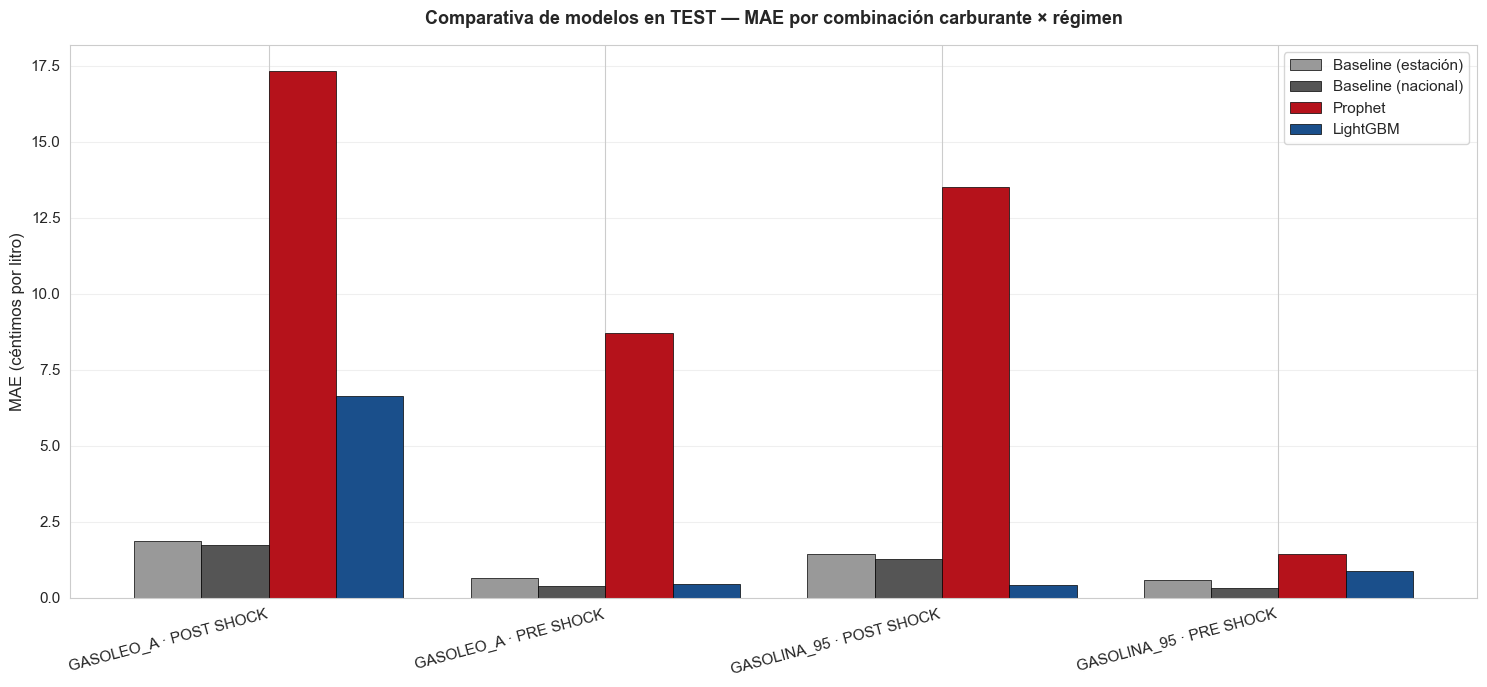

Figura guardada: comparativa_modelos_test.png


In [20]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(15, 7))

# Preparar datos
df_plot = todos_test.copy()
df_plot["modelo_etiqueta"] = pd.Categorical(
    df_plot["modelo_etiqueta"],categories=orden_modelos,ordered=True,)
df_plot = df_plot.sort_values(["combinacion", "modelo_etiqueta"])

# Colores por modelo
colores = {
    "Baseline (estación)": "#999999",
    "Baseline (nacional)": "#555555",
    "Prophet": "#B5121B",
    "LightGBM": "#1A4F8B",}

# Barras agrupadas
combinaciones = df_plot["combinacion"].unique()
n_combinaciones = len(combinaciones)
ancho = 0.2
x = np.arange(n_combinaciones)

for i, modelo in enumerate(orden_modelos):
    valores = []
    for comb in combinaciones:
        v = df_plot[(df_plot["combinacion"] == comb) &(df_plot["modelo_etiqueta"] == modelo)]["mae_cts"].values
        valores.append(v[0] if len(v) > 0 else np.nan)
    
    ax.bar(x + i*ancho - 1.5*ancho, valores, ancho,label=modelo, color=colores[modelo], edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(combinaciones, rotation=15, ha="right")
ax.set_ylabel("MAE (céntimos por litro)", fontsize=12)
ax.set_title("Comparativa de modelos en TEST — MAE por combinación carburante × régimen",fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "comparativa_modelos_test.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig.name}")

## Importancia de features en LightGBM

Analizamos qué variables son las más relevantes para el modelo LightGBM ganador. Esto nos da interpretabilidad del modelo y nos ayuda a entender qué dimensiones del problema captura mejor.

In [21]:
# Cargar los 4 modelos LightGBM y analizar importancia de features
print("=" * 80)
print("IMPORTANCIA DE FEATURES — Modelos LightGBM")
print("=" * 80)

combinaciones_lgb = [
    ("gasoleo_a", "pre_shock", "Gasóleo A · Pre-shock"),
    ("gasoleo_a", "post_shock", "Gasóleo A · Post-shock"),
    ("gasolina_95", "pre_shock", "Gasolina 95 · Pre-shock"),
    ("gasolina_95", "post_shock", "Gasolina 95 · Post-shock"),]

importancias_todos = {}

for carburante, regimen, etiqueta in combinaciones_lgb:
    ruta = CARPETA_MODELOS_LGB / f"lightgbm_{carburante}_{regimen}.txt"
    modelo = cargar_modelo_lightgbm(ruta)
    
    # Extraer importancia (con la API Booster)
    importancia = pd.DataFrame({"feature": modelo.feature_name(),"importance": modelo.feature_importance(importance_type="gain"),})
    importancia = importancia.sort_values("importance", ascending=False)
    importancia["importance_pct"] = (importancia["importance"] / importancia["importance"].sum() * 100).round(2)
    
    importancias_todos[etiqueta] = importancia
    
    print(f"\n>>> {etiqueta}")
    print("-" * 60)
    print(importancia.head(10).to_string(index=False))

print("\nImportancias calculadas para los 4 modelos")

IMPORTANCIA DE FEATURES — Modelos LightGBM

>>> Gasóleo A · Pre-shock
------------------------------------------------------------
                  feature    importance  importance_pct
             precio_lag_1 741188.979748           80.83
              precio_mm_7 168639.264838           18.39
  diferencial_vs_nacional   3810.076312            0.42
precio_medio_nacional_dia   1548.076138            0.17
             precio_lag_7   1238.665708            0.14
                      mes    204.008713            0.02
         dias_desde_shock    186.468257            0.02
           semana_del_año     49.722774            0.01
             precio_mm_30     44.716970            0.00
       Rotulo_normalizado     34.860287            0.00

>>> Gasóleo A · Post-shock
------------------------------------------------------------
                  feature    importance  importance_pct
             precio_lag_1 105177.897201           75.48
              precio_mm_7  14411.151638           10

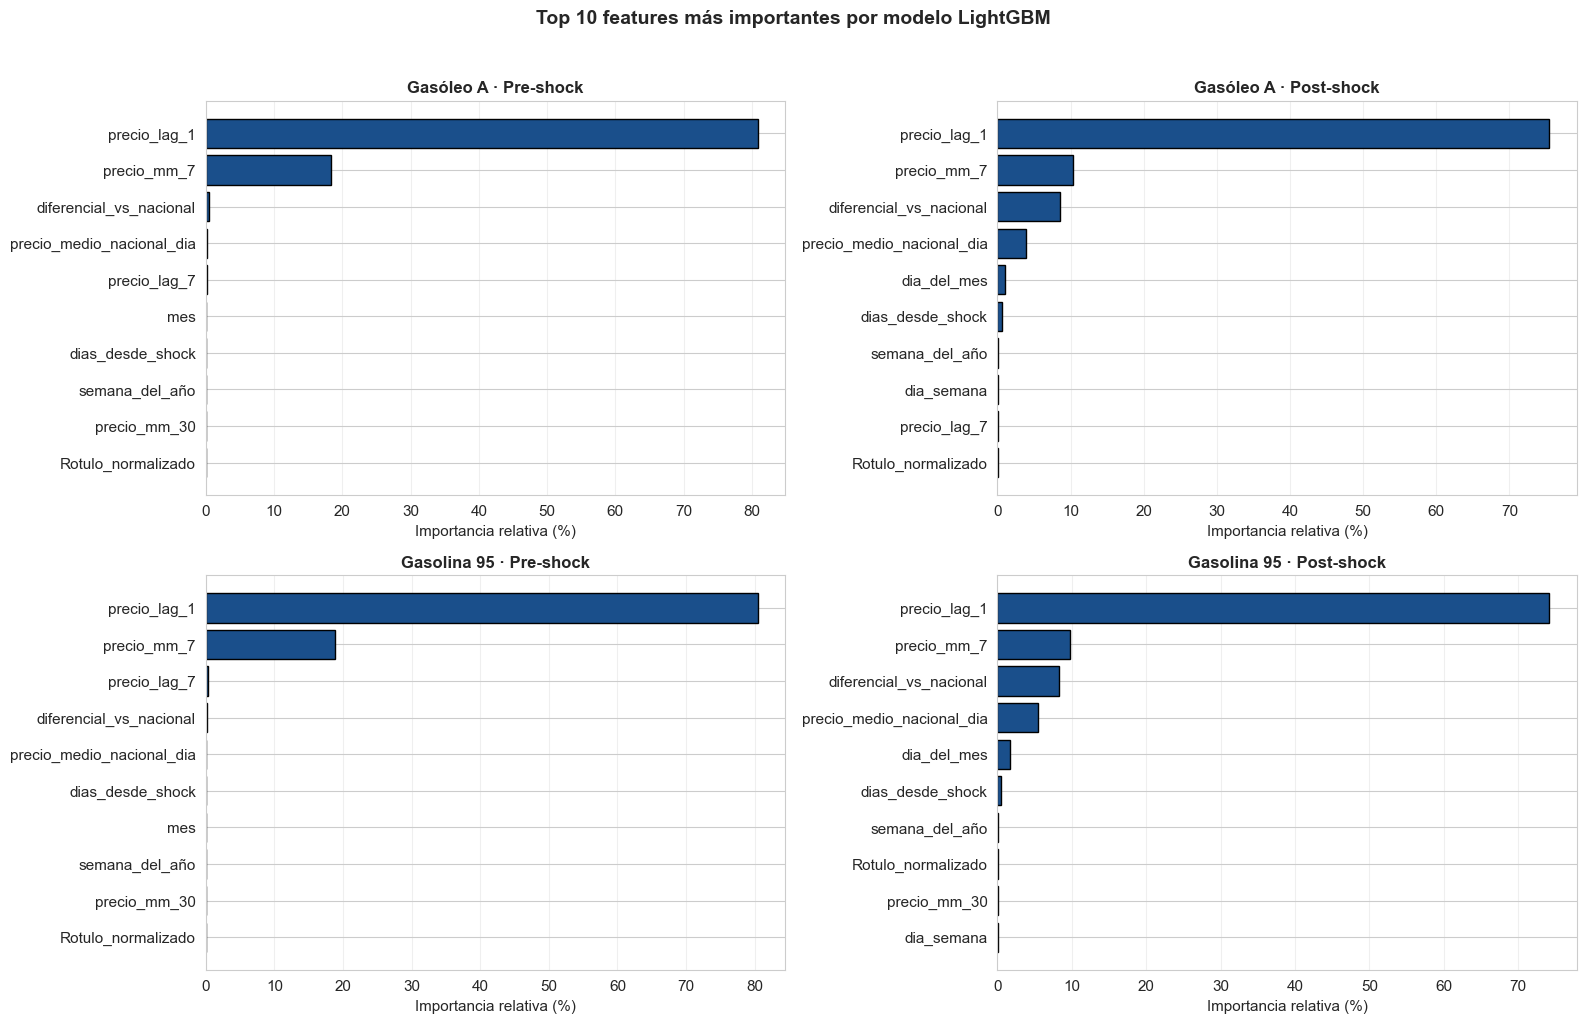

Figura guardada: importancia_features_lightgbm.png


In [22]:
# Visualización: importancia comparada de features (top 10)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (etiqueta, importancia) in enumerate(importancias_todos.items()):
    top10 = importancia.head(10).iloc[::-1]  # invertir para que el más importante esté arriba
    
    axes[i].barh(top10["feature"], top10["importance_pct"], color="#1A4F8B", edgecolor="black")
    axes[i].set_title(etiqueta, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Importancia relativa (%)")
    axes[i].grid(True, axis="x", alpha=0.3)

plt.suptitle("Top 10 features más importantes por modelo LightGBM",fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "importancia_features_lightgbm.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig.name}")

## Decisión final: modelo de producción

A partir del análisis cuantitativo y funcional, se establece la selección formal del modelo de producción del sistema RepostaPro.

### Comparativa cualitativa de los 4 modelos evaluados

| Modelo | MAE en test | Granularidad | Coste computacional | Aptitud para producción |
|---|---|---|---|---|
| **Baseline (estación)** | 0,59-1,87 cts | Individual | Cero (regla aritmética) | Limitado: no aprovecha features |
| **Baseline (nacional)** | 0,32-1,74 cts | Agregada nacional | Cero | **No apto**: no predice estaciones individuales |
| **Prophet** | 1,43-17,32 cts | Agregada nacional | Medio | **No apto**: peor que baseline y sin granularidad |
| **LightGBM** | 0,40-6,64 cts | Individual | Medio (3 min/modelo) | **APTO**: predice cada estación y compite con baseline naive |

### Justificación de la selección

El modelo de producción del sistema RepostaPro es **LightGBM** por las siguientes razones combinadas:

1. **Granularidad funcional**: es el único modelo capaz de producir predicciones individualizadas por estación, requerimiento operativo central de RepostaPro.

2. **Precisión competitiva**: alcanza MAE de 0,40-0,87 cts en tres de cuatro combinaciones, equivalente al baseline naive aplicado a un problema más complejo (predicción individual vs. agregada).

3. **Aprovechamiento de features**: integra las 18 variables del feature engineering, incluyendo categóricas geográficas (marca, provincia, CCAA) y lags temporales por estación, información que ningún otro modelo del estudio puede explotar simultáneamente.

4. **Robustez en régimen post-shock**: en la combinación más desafiante (Gasolina 95 post-shock), LightGBM bate a todos los modelos competidores con un MAE de 0,40 cts.

### Limitaciones reconocidas

- **Gasóleo A post-shock con MAE de 6,64 cts**: el régimen post-shock del Gasóleo A presenta tres sub-fases estructuralmente distintas (pico, transición fiscal, estabilización) en apenas 106 días, lo que dificulta el aprendizaje del modelo. Se identifica como **línea futura de mejora** la aplicación de optimización bayesiana de hiperparámetros (Optuna) y/o la incorporación de variables exógenas macro (precio del crudo Brent, indicadores de tensión geopolítica).
- **El Baseline nacional supera a LightGBM en pure MAE** en tres combinaciones: esta inferioridad métrica se justifica funcionalmente: el Baseline nacional no es operativamente útil al no producir predicciones individualizadas, requerimiento crítico del sistema.

In [23]:
# Resumen
print("=" * 80)
print("RESUMEN")
print("=" * 80)

print("""
COMPARATIVA DE MODELOS EVALUADOS:
  • Baseline (estación):    Referencia mínima por estación.
  • Baseline (nacional):    Referencia mínima agregada nacional.
  • Prophet (Meta):         Series temporales con descomposición.
  • LightGBM (Microsoft):   Gradient boosting tabular.

GANADOR POR MÉTRICA PURA (MAE en test):
  • 3 de 4 combinaciones:   Baseline (nacional)
  • 1 de 4 combinaciones:   LightGBM (Gasolina 95 post-shock)

GANADOR FUNCIONAL (selección de producción):
  >>> LightGBM <<<
  Único modelo capaz de producir predicciones individualizadas por estación,
  requerimiento central del sistema RepostaPro.

MÉTRICAS DE LIGHTGBM EN TEST:
  • Gasóleo A · Pre-shock:        MAE 0,46 cts (MAPE 0,33 %)
  • Gasóleo A · Post-shock:       MAE 6,64 cts (MAPE 4,09 %)
  • Gasolina 95 · Pre-shock:      MAE 0,87 cts (MAPE 0,61 %)
  • Gasolina 95 · Post-shock:     MAE 0,40 cts (MAPE 0,27 %)""")

RESUMEN

COMPARATIVA DE MODELOS EVALUADOS:
  • Baseline (estación):    Referencia mínima por estación.
  • Baseline (nacional):    Referencia mínima agregada nacional.
  • Prophet (Meta):         Series temporales con descomposición.
  • LightGBM (Microsoft):   Gradient boosting tabular.

GANADOR POR MÉTRICA PURA (MAE en test):
  • 3 de 4 combinaciones:   Baseline (nacional)
  • 1 de 4 combinaciones:   LightGBM (Gasolina 95 post-shock)

GANADOR FUNCIONAL (selección de producción):
  >>> LightGBM <<<
  Único modelo capaz de producir predicciones individualizadas por estación,
  requerimiento central del sistema RepostaPro.

MÉTRICAS DE LIGHTGBM EN TEST:
  • Gasóleo A · Pre-shock:        MAE 0,46 cts (MAPE 0,33 %)
  • Gasóleo A · Post-shock:       MAE 6,64 cts (MAPE 4,09 %)
  • Gasolina 95 · Pre-shock:      MAE 0,87 cts (MAPE 0,61 %)
  • Gasolina 95 · Post-shock:     MAE 0,40 cts (MAPE 0,27 %)
